In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('data/hotel_bookings.csv')

In [4]:
df['children'] = df['children'].fillna(0)
df['country'] = df['country'].fillna('Unknown')

In [5]:
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df['month_num'] = df['arrival_date_month'].map(month_map)
df['arrival_date'] = pd.to_datetime(df[['arrival_date_year', 'month_num', 'arrival_date_day_of_month']]
                                     .rename(columns={'arrival_date_year': 'year', 'month_num': 'month', 'arrival_date_day_of_month': 'day'}))

In [6]:
total_bookings = len(df)
cancellation_rate = df['is_canceled'].mean() * 100
no_show_rate = (df['reservation_status'] == 'No-Show').mean() * 100

In [7]:
print(f"Total Bookings Analyzed: {total_bookings}")
print(f"Overall Cancellation Rate: {cancellation_rate:.2f}%")
print(f"No-Show Rate: {no_show_rate:.2f}%")

Total Bookings Analyzed: 119390
Overall Cancellation Rate: 37.04%
No-Show Rate: 1.01%


In [8]:
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

In [9]:
plt.figure(figsize=(18, 12))

<Figure size 1800x1200 with 0 Axes>

<Figure size 1800x1200 with 0 Axes>

In [10]:
monthly_counts = df.groupby(['arrival_date_year', 'month_num', 'arrival_date_month']).agg({'is_canceled': ['count', 'sum']}).reset_index()
monthly_counts.columns = ['year', 'month_num', 'month_name', 'total_bookings', 'cancellations']
monthly_counts = monthly_counts.sort_values(['year', 'month_num'])
monthly_counts['label'] = monthly_counts['month_name'] + " " + monthly_counts['year'].astype(str)

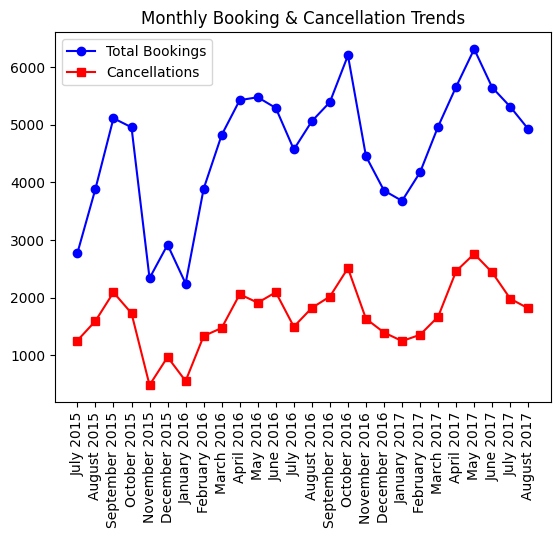

In [11]:
plt.subplot(1,1,1)
plt.plot(monthly_counts['label'], monthly_counts['total_bookings'], marker='o', label='Total Bookings', color='blue')
plt.plot(monthly_counts['label'], monthly_counts['cancellations'], marker='s', label='Cancellations', color='red')
plt.title('Monthly Booking & Cancellation Trends')
plt.xticks(rotation=90)
plt.legend()

C:\Users\Testing\AppData\Local\Temp\ipykernel_12540\4223119112.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.index, y=top_countries.values, palette='viridis')


Text(0.5, 1.0, 'Top 10 Countries by Confirmed Bookings')

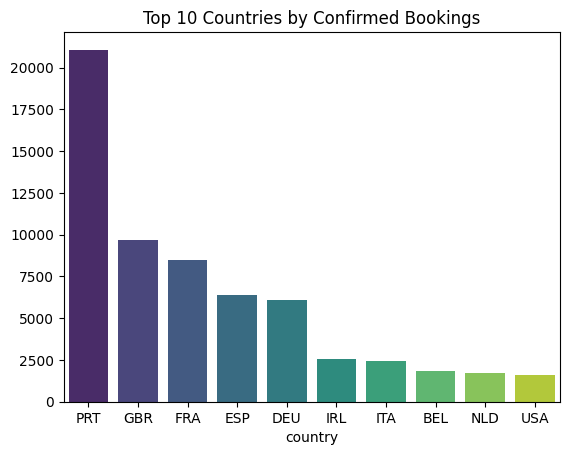

In [12]:
top_countries = df[df['is_canceled'] == 0]['country'].value_counts().head(10)
plt.subplot(1,1,1)
sns.barplot(x=top_countries.index, y=top_countries.values, palette='viridis')
plt.title('Top 10 Countries by Confirmed Bookings')

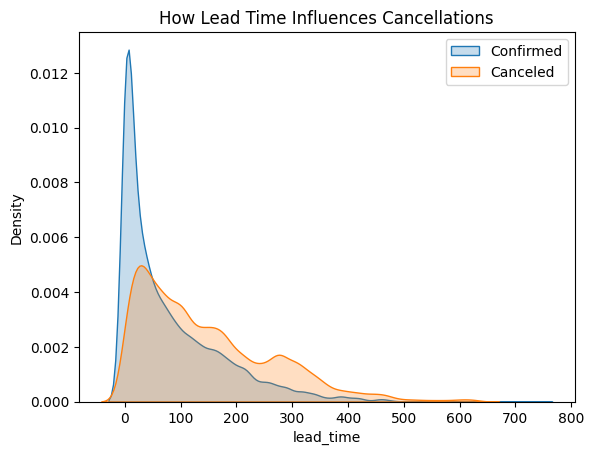

In [14]:
plt.subplot(1,1,1)
sns.kdeplot(data=df[df['is_canceled'] == 0], x='lead_time', label='Confirmed', fill=True)
sns.kdeplot(data=df[df['is_canceled'] == 1], x='lead_time', label='Canceled', fill=True)
plt.title('How Lead Time Influences Cancellations')
plt.legend()

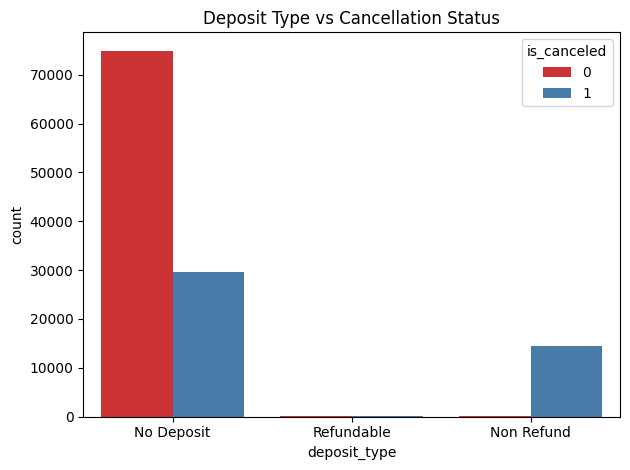

In [15]:
plt.subplot(1,1,1)
sns.countplot(x='deposit_type', hue='is_canceled', data=df, palette='Set1')
plt.title('Deposit Type vs Cancellation Status')

plt.tight_layout()
plt.show()